# CLASSIFICATION WITH AN IMBALANCED DATASET
The objective of this code is to train a machine learning algorithm in identifying fraudulent transactions. Two models were tested.

Step 1. Import Libraries and Load Dataset´

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "10"

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [2]:
fraud_df = pd.read_csv('card_transdata.csv')
# https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud/data

Step 2. Data Analysis and Visualization

In [3]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [4]:
fraud_df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Analize data imbalance
fraud_df.fraud.value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

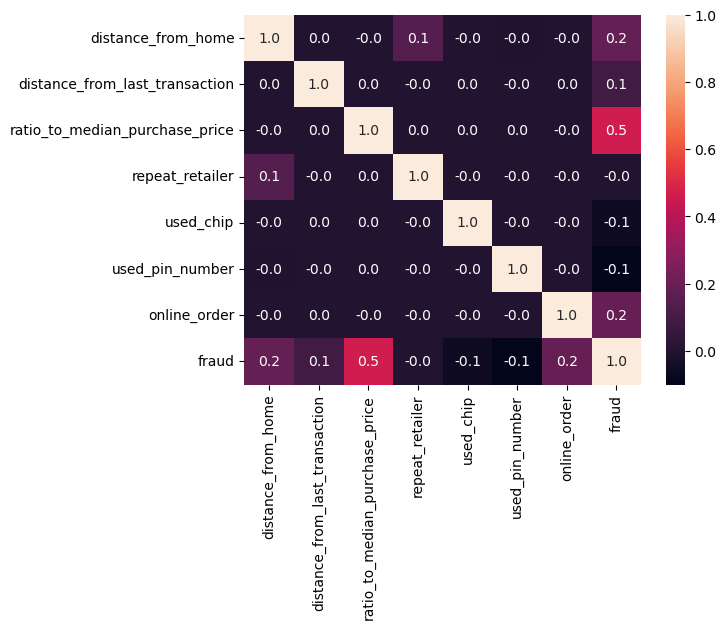

In [6]:
# Visualize correlations
def show_heatmap(df):
    sn.heatmap(data = df.corr(), annot = True, fmt='.1f')
    plt.show()

show_heatmap(fraud_df)

In [7]:
# Since repeat_retailer has no correlation with the target (fraud), it will be removed from the dataset as it is a potential source of noise
fraud_df.drop('repeat_retailer', axis=1, inplace=True)

Step 3. Data Cleaning

There will be no outliers removal, since outlier values in the features distance_from_home, distance_from_last_transaction andratio_to_median_purchase_price could be perfect indicators for fraud detection. These outliers make the data hard to normalize or standardize, thus a robust scaling would be a better option.

Removal of duplicated data won't be executed either, for dulpicated instances in this case may also contain useful information for the task

In [8]:
# Find missing values
for feature in fraud_df.columns:
    print(f'Total missing values for {feature}: {fraud_df[feature].isna().sum()}')

Total missing values for distance_from_home: 0
Total missing values for distance_from_last_transaction: 0
Total missing values for ratio_to_median_purchase_price: 0
Total missing values for used_chip: 0
Total missing values for used_pin_number: 0
Total missing values for online_order: 0
Total missing values for fraud: 0


Step 4. Data Transformation

Since we are dealing with an imbalanced datset, either oversampling or undersampling is required to avoid bias in the final classifier. Oversampling increases the risk of overfitting, while undersampling increases the risk of information loss. With almost 1M instances, it is less probable to lose information by undersampling than it is to overfit bu oversampling. There is also the factor that a personal computer (like mine) will take too long for training multiple algorithms with an oversampled dataset of 2M instances.
For these two reasons, I will perform undersampling on the majority class.

In [ ]:
def undersample_data(df):
    y = df.fraud
    X = df.drop(columns=['fraud'])
    rus = RandomUnderSampler(random_state=0)

    '''
    Though I would have preferred to use ClusterCentroids for undersampling,
    execution time for this dataset size with my computer is excesive
    '''
   
    X_resampled, y_resampled = rus.fit_resample(X, y)
    df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
    df_resampled['fraud'] = y_resampled
    return df_resampled

u_fraud_df = undersample_data(fraud_df)
u_fraud_df.fraud.value_counts()

fraud
0.0    87403
1.0    87403
Name: count, dtype: int64

In [13]:
y = u_fraud_df.fraud
X = u_fraud_df.drop(columns=['fraud'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def transform_data(X_train, X_test):
    'Since there are many outliers in the data, I chose to use a robust scaler'
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = transform_data(X_train, X_test)
print(y_test.value_counts())
X_train_scaled

fraud
1.0    17488
0.0    17474
Name: count, dtype: int64


array([[-0.32356883,  0.18637398,  1.13801089,  0.        ,  0.        ,
        -1.        ],
       [-0.05357444,  0.08263637,  0.08280537,  0.        ,  0.        ,
         0.        ],
       [-0.21631908, -0.26921304,  0.88346893,  0.        ,  0.        ,
         0.        ],
       ...,
       [ 0.01724116,  0.13786447,  0.58119864,  0.        ,  0.        ,
         0.        ],
       [ 0.13985993,  0.27931888,  0.51524385,  0.        ,  0.        ,
         0.        ],
       [ 0.89456157,  0.66909081,  0.56772997,  1.        ,  0.        ,
         0.        ]], shape=(139844, 6))

Step 5. Train and Compare Models

In [11]:
def train_rf(X80, X20, y80, y20):
    clf = RandomForestClassifier()

    # Find best parameters for the model
    grid_values = {'n_estimators': [25, 50, 75, 100], 'max_features': [2, 3, 4], 'max_depth' : [2, 3]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    # Test accuracy for train and test (to look for best model and assure no overfitting is happening)
    y20_predicted = best_model.predict(X20)
    y80_predicted = best_model.predict(X80)

    return (f'train accuracy = {accuracy_score(y80, y80_predicted)}, test accuracy = {accuracy_score(y20, y20_predicted)}')

def train_gb(X80, X20, y80, y20):
    #clf = GradientBoostingClassifier()
    clf = HistGradientBoostingClassifier(max_iter=500)

    # Find best parameters for the model
    grid_values = {'max_depth' : [3, 4], 'learning_rate': [0.01, 0.05, 0.2]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    # Test accuracy for train and test (to look for best model and assure no overfitting is happening)
    y20_predicted = best_model.predict(X20)
    y80_predicted = best_model.predict(X80)

    return (f'train accuracy = {accuracy_score(y80, y80_predicted)}, test accuracy = {accuracy_score(y20, y20_predicted)}')

def train_models(X80, X20, y80, y20):
    results = dict()
    results['Random Forest'] = train_rf(X80, X20, y80, y20)
    results['Gradient Boosting'] = train_gb(X80, X20, y80, y20)
    return results


# Train different models and return their accuracy to compare their performance
model_scores = train_models(X_train_scaled, X_test_scaled, y_train, y_test)
model_scores

{'Random Forest': 'train accuracy = 0.9770601527416264, test accuracy = 0.9766889766031691',
 'Gradient Boosting': 'train accuracy = 0.9977903950115843, test accuracy = 0.9977690063497512'}